In [10]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("../data/processed/english_hindi.csv")

X = df['clean_text']
y = df['labels']

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# TF-IDF
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(8229, 13927)
(2058, 13927)


In [20]:
#model1 Multinomial Naive Bayes

from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf,y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

In [21]:
#model2 Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter = 1000,class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

In [22]:
#Model3 Linear SVM
from sklearn.svm import LinearSVC
svm_model = LinearSVC(class_weight='balanced', random_state=42)

svm_model.fit(X_train_tfidf,y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

evaluation of all three models

In [23]:
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score,classification_report)
def evaluate_model(name, y_true, y_pred):
    print(name)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    ))

multinomial naive bayes

In [24]:
evaluate_model(
    "Multinomial Naive Bayes",
    y_test,
    y_pred_nb
)

Multinomial Naive Bayes
Accuracy : 0.9373177842565598
Precision: 1.0
Recall   : 0.4921259842519685
F1 Score : 0.6596306068601583

Classification Report:
              precision    recall  f1-score   support

         ham       0.93      1.00      0.97      1804
        spam       1.00      0.49      0.66       254

    accuracy                           0.94      2058
   macro avg       0.97      0.75      0.81      2058
weighted avg       0.94      0.94      0.93      2058



In [25]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

Logistic Regression
Accuracy : 0.9533527696793003
Precision: 0.7743055555555556
Recall   : 0.8779527559055118
F1 Score : 0.8228782287822878

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.96      0.97      1804
        spam       0.77      0.88      0.82       254

    accuracy                           0.95      2058
   macro avg       0.88      0.92      0.90      2058
weighted avg       0.96      0.95      0.95      2058



In [26]:
evaluate_model(
    "Linear SVM",
    y_test,
    y_pred_svm
)

Linear SVM
Accuracy : 0.9582118561710399
Precision: 0.8387096774193549
Recall   : 0.8188976377952756
F1 Score : 0.8286852589641435

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      0.98      0.98      1804
        spam       0.84      0.82      0.83       254

    accuracy                           0.96      2058
   macro avg       0.91      0.90      0.90      2058
weighted avg       0.96      0.96      0.96      2058



confusion matrix

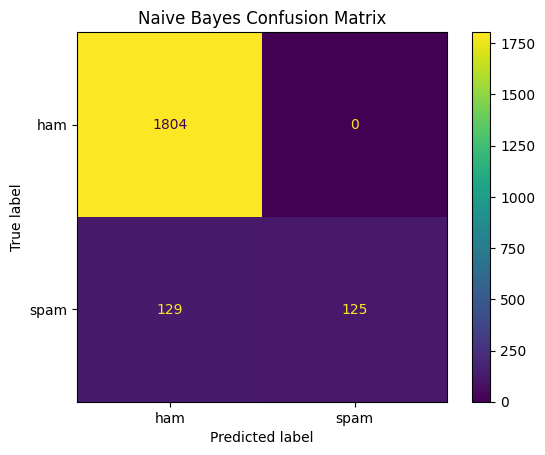

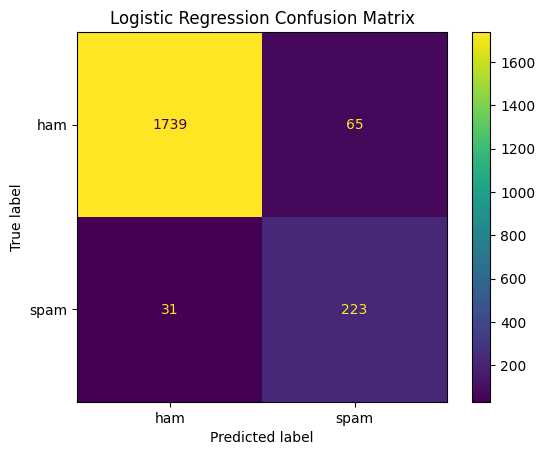

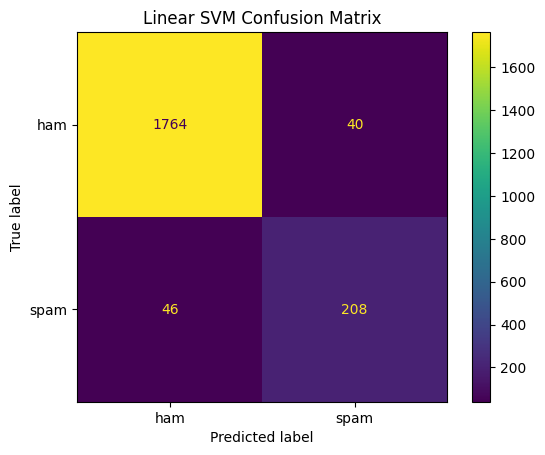

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


#naive bayes
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    display_labels=label_encoder.classes_
)

plt.title("Naive Bayes Confusion Matrix")
plt.show()

#logistic regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=label_encoder.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

#svm
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=label_encoder.classes_
)

plt.title("Linear SVM Confusion Matrix")
plt.show()

In [28]:
results = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'Logistic Regression',
        'Linear SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.937318,1.000000,0.492126,0.659631
1,Logistic Regression,0.953353,0.774306,0.877953,0.822878
2,Linear SVM,0.958212,0.838710,0.818898,0.828685
